Colab of strabismus analysis using neural networks

In [73]:
import pandas as pd
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import random
import tensorflow as tf
from tensorflow.keras import callbacks, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model



In [74]:
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            #tf.config.experimental.set_memory_growth(gpu, True)
             # Disable all GPUs by setting an empty list of visible devices
            tf.config.set_visible_devices([], 'GPU')
            print(gpu)
    except RuntimeError as e:
        print("Error:",e)
else:
    print("No GPU found")

No GPU found


In [75]:
BASE_PATH = '../Dataset'
list_of_cases = os.listdir(BASE_PATH)
list_of_cases

['ESOTROPIA', 'HYPERTROPIA', 'NORMAL', 'HYPOTROPIA', 'EXOTROPIA']

In [76]:
classes = ['esotropia',
 'exotropia',
 'hypertropia',
 'hypotropia']

In [77]:
classes = [x.upper() for x in classes]
classes

['ESOTROPIA', 'EXOTROPIA', 'HYPERTROPIA', 'HYPOTROPIA']

In [78]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [79]:
label_map = {y:x for x,y in enumerate(classes)}
label_map

{'ESOTROPIA': 0, 'EXOTROPIA': 1, 'HYPERTROPIA': 2, 'HYPOTROPIA': 3}

In [80]:
for case in list_of_cases:
    print(f'Processing case: {case}')

Processing case: ESOTROPIA
Processing case: HYPERTROPIA
Processing case: NORMAL
Processing case: HYPOTROPIA
Processing case: EXOTROPIA


In [133]:
images = []
labels = []
filenames = []
count = 0
treated_data = {}

for folder in list_of_cases:
  if folder in classes:
    count2 = 0
    list_of_files = os.listdir(os.path.join(BASE_PATH, folder))
    print(f'Processing case: {folder}')

    if folder != 'NORMAL':

      for file_ in list_of_files:
        #print(f'file_: {file_}')
        if 'exc' not in file_:
          pass
        img = cv.imread(os.path.join(BASE_PATH, folder, file_))
        if img is not None:
          img2 = cv.resize(img, (224, 96), interpolation=cv.INTER_AREA)
          img2 = cv.cvtColor(img2, cv.COLOR_BGR2RGB)
          img2 = img2.astype('float32') / 255.0
          images.append(img2)
          labels.append(label_map[folder])
          filenames.append(file_)
          count += 1
          count2+= 1
      treated_data[folder] = count2
print(f"Number of images processed: {count}")

Processing case: ESOTROPIA
Processing case: HYPERTROPIA
Processing case: HYPOTROPIA
Processing case: EXOTROPIA
Number of images processed: 399


In [134]:
treated_data = pd.DataFrame(treated_data.items(), columns=['Case', 'Count'])

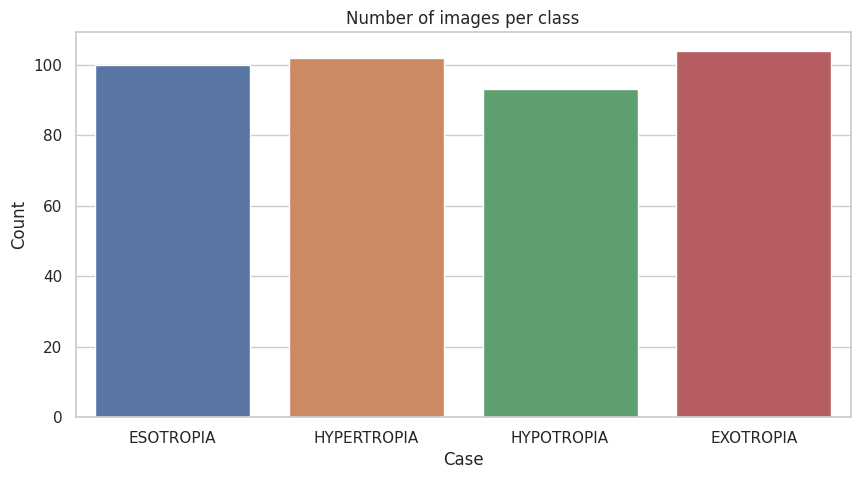

In [111]:
# Print the number of images per class
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(x='Case', y='Count', data=treated_data)
plt.title('Number of images per class')
plt.show()

In [135]:
# Convertendo as listas para numpy
images = np.array(images)
labels = np.array(labels)

In [136]:
print(images.shape)
print(labels.shape)

(399, 96, 224, 3)
(399,)


In [137]:
# Realizando o one hot encoding
num_of_classes = len(classes)
labels = tf.keras.utils.to_categorical(labels, num_of_classes)

In [138]:
# Shuffle dataset
indices = np.arange(len(images))
np.random.shuffle(indices)


In [139]:
images = images[indices]
labels = labels[indices]

In [140]:
# Separando as imagens
train_images = images[:int(0.68*len(images))]
train_labels = labels[:int(0.68*len(labels))]
val_images = images[int(0.68*len(images)):int(0.7*len(images))]
val_labels = labels[int(0.68*len(images)):int(0.7*len(images))]
test_images = images[int(0.7*len(images)):]
test_labels = labels[int(0.7*len(labels)):]

In [141]:
print(train_images.shape)
print(train_labels.shape)
print(test_images.shape)
print(test_labels.shape)
print(val_images.shape)
print(val_labels.shape)

(271, 96, 224, 3)
(271, 4)
(120, 96, 224, 3)
(120, 4)
(8, 96, 224, 3)
(8, 4)


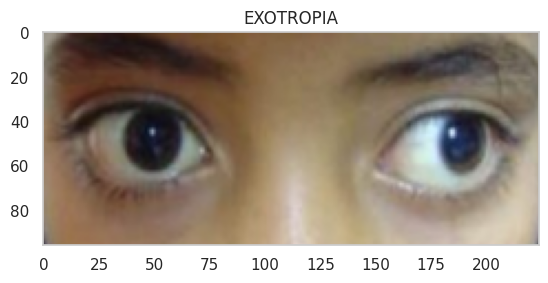

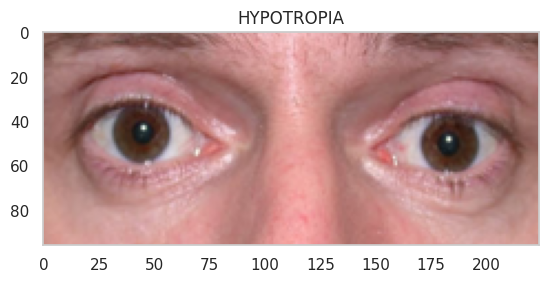

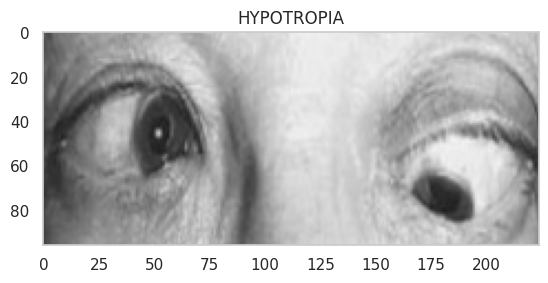

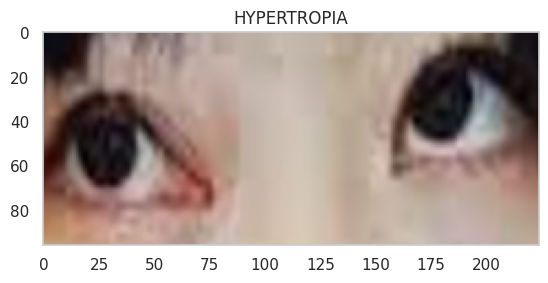

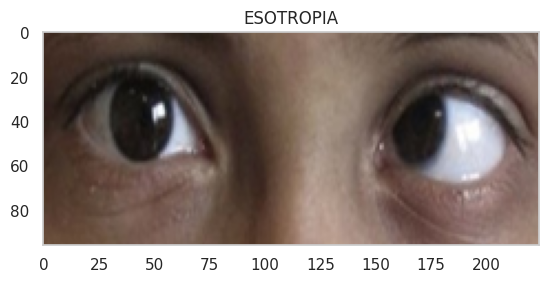

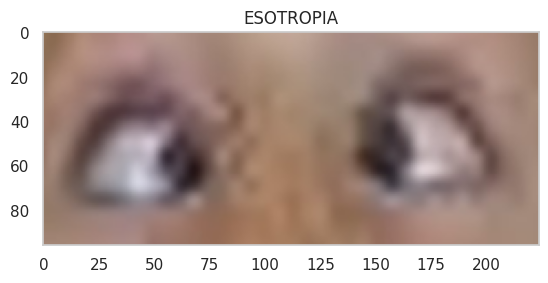

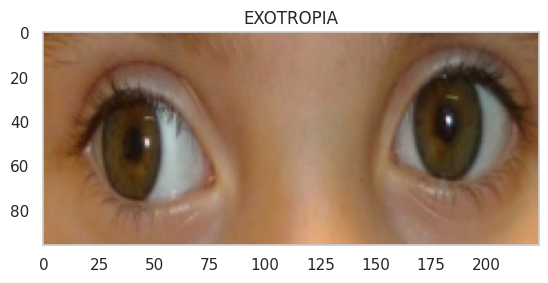

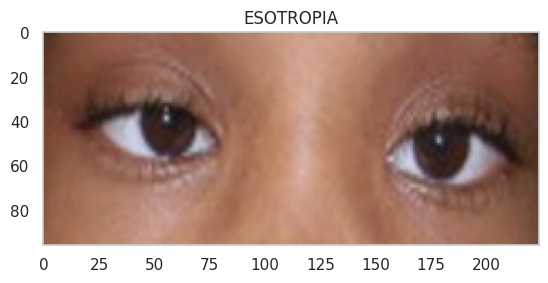

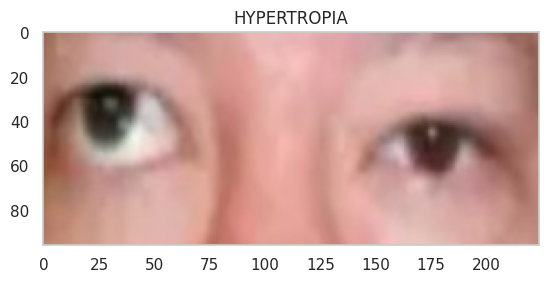

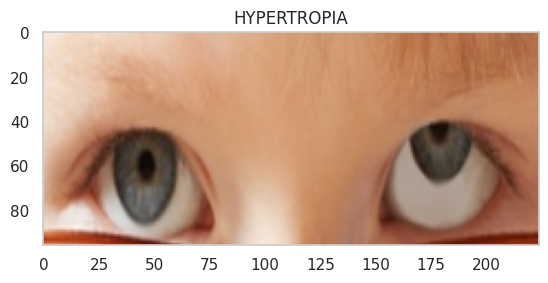

In [142]:
# print some images
for i in range(10):
    plt.imshow(train_images[i])
    plt.title(classes[np.argmax(train_labels[i])])
    plt.grid(False)
    plt.show()

In [143]:
input_shape = train_images.shape[1:]
print(input_shape)

(96, 224, 3)


In [144]:
# Carregando o Modelo baseado na Resnet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
base_model.trainable = False

In [145]:
# Customizando o modelo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)

predictions = Dense(num_of_classes, activation='softmax')(x)

In [146]:
# Juntando o modelo completo
model = Model(inputs=base_model.input, outputs=predictions)

In [147]:
model.compile(optimizer=optimizers.Adam(learning_rate = 0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "model_6"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_6 (InputLayer)            [(None, 96, 224, 3)] 0                                            
__________________________________________________________________________________________________
conv1_pad (ZeroPadding2D)       (None, 102, 230, 3)  0           input_6[0][0]                    
__________________________________________________________________________________________________
conv1_conv (Conv2D)             (None, 48, 112, 64)  9472        conv1_pad[0][0]                  
__________________________________________________________________________________________________
conv1_bn (BatchNormalization)   (None, 48, 112, 64)  256         conv1_conv[0][0]                 
____________________________________________________________________________________________

In [148]:
tensorboard_callback = callbacks.TensorBoard(log_dir='../logs')

2025-03-06 17:40:33.619461: I tensorflow/core/profiler/lib/profiler_session.cc:136] Profiler session initializing.
2025-03-06 17:40:33.619480: I tensorflow/core/profiler/lib/profiler_session.cc:155] Profiler session started.
2025-03-06 17:40:33.619511: I tensorflow/core/profiler/lib/profiler_session.cc:172] Profiler session tear down.


In [149]:
import datetime
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
current_time = current_time[:current_time.index('-')]
print(current_time)

20250306


In [ ]:
class TestEvaluationCallback(callbacks.Callback):
    def __init__(self, test_data, filepath):
        super(TestEvaluationCallback, self).__init__()
        self.test_data = test_data
        self.test_losses = []
        self.test_accuracies = []
        self.best_accuracy  = 0.5
        self.filepath = filepath
        self.current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    def on_epoch_end(self, epoch, logs=None):
        x, y = self.test_data
        loss, accuracy = self.model.evaluate(x, y, verbose=0)
        self.test_losses.append(loss)
        self.test_accuracies.append(accuracy)
        print(f"\nEpoch: {epoch + 1} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

        if accuracy > self.best_accuracy:
            x, y = self.test_data
            loss, accuracy = self.model.evaluate(x, y, verbose=0)
            self.test_losses.append(loss)
            self.test_accuracies.append(accuracy)
            print(f"\nEpoch: {epoch + 1} Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

            self.best_accuracy = accuracy
            date = self.current_time[:self.current_time.index("-")]
            fileName = os.path.join(self.filepath, f"best_model_{date}.h5")
            self.model.save(fileName)
            print(f"Saved best model with accuracy: {accuracy:.4f}")
                

In [151]:
model_path = '../Models'
if not os.path.exists(model_path):
    os.makedirs(model_path)
test_eval_callback = TestEvaluationCallback((test_images, test_labels), model_path)

In [152]:
# Train the Model
epochs = 2000
history = model.fit(train_images, train_labels, epochs=epochs, batch_size=16, validation_data=(val_images, val_labels), callbacks=[tensorboard_callback, test_eval_callback])

Epoch 1/2000
 1/17 [>.............................] - ETA: 28s - loss: 1.4169 - accuracy: 0.1250

2025-03-06 17:40:43.861655: I tensorflow/core/profiler/lib/profiler_session.cc:136] Profiler session initializing.
2025-03-06 17:40:43.861675: I tensorflow/core/profiler/lib/profiler_session.cc:155] Profiler session started.


 2/17 [==>...........................] - ETA: 3s - loss: 1.4608 - accuracy: 0.1094 

2025-03-06 17:40:44.198799: I tensorflow/core/profiler/lib/profiler_session.cc:71] Profiler session collecting data.
2025-03-06 17:40:44.202117: I tensorflow/core/profiler/lib/profiler_session.cc:172] Profiler session tear down.
2025-03-06 17:40:44.205392: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: ../logs/train/plugins/profile/2025_03_06_17_40_44
2025-03-06 17:40:44.208393: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for trace.json.gz to ../logs/train/plugins/profile/2025_03_06_17_40_44/pedro-Z590-AORUS-ELITE.trace.json.gz
2025-03-06 17:40:44.212213: I tensorflow/core/profiler/rpc/client/save_profile.cc:137] Creating directory: ../logs/train/plugins/profile/2025_03_06_17_40_44
2025-03-06 17:40:44.212300: I tensorflow/core/profiler/rpc/client/save_profile.cc:143] Dumped gzipped tool data for memory_profile.json.gz to ../logs/train/plugins/profile/2025_03_06_17_40_44/pedro-Z590-AORUS-ELITE.memory_profile.json.gz

17/17 [==============================] - 6s 255ms/step - loss: 1.4749 - accuracy: 0.1722 - val_loss: 1.3683 - val_accuracy: 0.5000

Epoch: 1 Test Loss: 1.4245, Test Accuracy: 0.2167
Epoch 2/2000
17/17 [==============================] - 4s 210ms/step - loss: 1.4624 - accuracy: 0.1935 - val_loss: 1.3578 - val_accuracy: 0.5000

Epoch: 2 Test Loss: 1.3938, Test Accuracy: 0.2167
Epoch 3/2000
17/17 [==============================] - 4s 208ms/step - loss: 1.4313 - accuracy: 0.2338 - val_loss: 1.3831 - val_accuracy: 0.5000

Epoch: 3 Test Loss: 1.4266, Test Accuracy: 0.2167
Epoch 4/2000
17/17 [==============================] - 4s 209ms/step - loss: 1.4129 - accuracy: 0.2809 - val_loss: 1.3221 - val_accuracy: 0.5000

Epoch: 4 Test Loss: 1.4109, Test Accuracy: 0.2167
Epoch 5/2000
17/17 [==============================] - 4s 209ms/step - loss: 1.4293 - accuracy: 0.2648 - val_loss: 1.3556 - val_accuracy: 0.5000

Epoch: 5 Test Loss: 1.4049, Test Accuracy: 0.2167
Epoch 6/2000
17/17 [==================

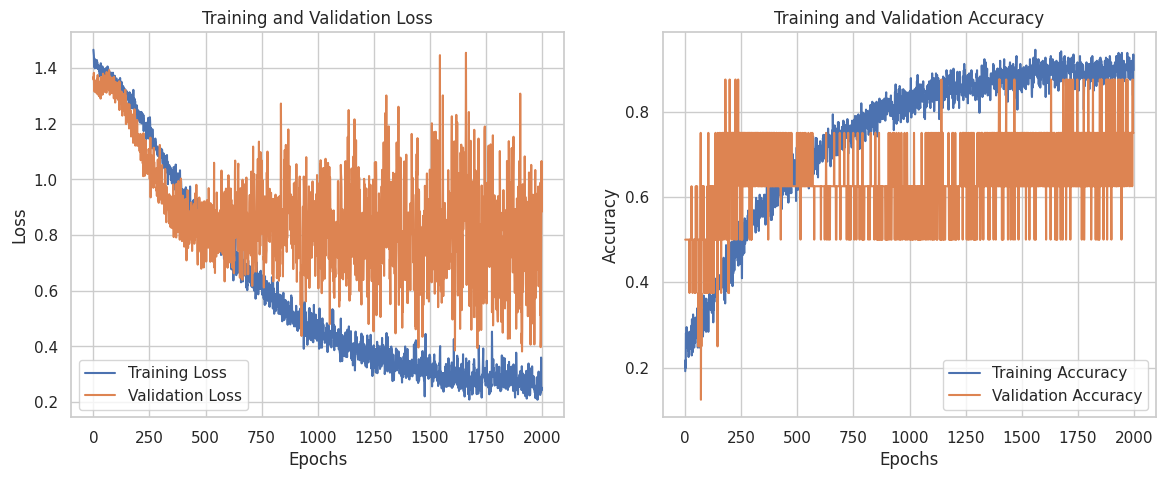

In [153]:
# Imprimindo o histórico de treinamento
# Loss
plt.figure(figsize = (14,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [154]:
# Model Evaluator
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, roc_curve, auc

class model_evaluator():
    def __init__(self, model_path, test_images, test_labels, classes):
        self.model_path = model_path
        self.test_images = test_images
        self.test_labels = test_labels
        self.model = tf.keras.models.load_model(self.model_path)
        self.class_names = classes

    def evaluate_model(self):
        predictions = self.model.predict(self.test_images)
        y_pred = np.argmax(predictions, axis=1)
        y_true = np.argmax(self.test_labels, axis=1)

        # Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        print(cm)

        # Classification Report
        cr = classification_report(y_true, y_pred, target_names=self.class_names)
        print(cr)

        # Calculate Specificity and Sensitivity
        sensitivity = {}
        specificity = {}

        for i in range(len(self.class_names)):
            TP = cm[i, i]
            FN = np.sum(cm[i, :]) - TP
            FP = np.sum(cm[:, i]) - TP
            TN = np.sum(cm) - TP - FN - FP

            sensitivity[self.class_names[i]] = TP / (TP + FN)
            specificity[self.class_names[i]] = TN / (TN + FP)

        # Print Sensitivity and Specificity for every class
        for key, value in sensitivity.items():
            print(f'{key} Sensitivity: {value}')
            print(f'{key} Specificity: {specificity[key]}')

    # Plotting the ROC Curve
    def plot_roc_curve(self):
        plt.figure(figsize=(10, 10))
        for i in range(len(self.class_names)):
            fpr, tpr, _ = roc_curve(self.test_labels[:, i], self.model.predict(self.test_images)[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'{self.class_names[i]} (AUC = {roc_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for random classifier
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curves')
        plt.legend(loc="lower right")
        plt.show()


    
    

In [159]:
evaluator = model_evaluator(model_path + '/best_model_epoch_430.h5', test_images, test_labels, classes)
evaluator.evaluate_model()


[[27  3  1  2]
 [ 6 21  6  0]
 [ 2 10 14  0]
 [ 3  5  6 14]]
              precision    recall  f1-score   support

   ESOTROPIA       0.71      0.82      0.76        33
   EXOTROPIA       0.54      0.64      0.58        33
 HYPERTROPIA       0.52      0.54      0.53        26
  HYPOTROPIA       0.88      0.50      0.64        28

    accuracy                           0.63       120
   macro avg       0.66      0.62      0.63       120
weighted avg       0.66      0.63      0.63       120

ESOTROPIA Sensitivity: 0.8181818181818182
ESOTROPIA Specificity: 0.8735632183908046
EXOTROPIA Sensitivity: 0.6363636363636364
EXOTROPIA Specificity: 0.7931034482758621
HYPERTROPIA Sensitivity: 0.5384615384615384
HYPERTROPIA Specificity: 0.8617021276595744
HYPOTROPIA Sensitivity: 0.5
HYPOTROPIA Specificity: 0.9782608695652174


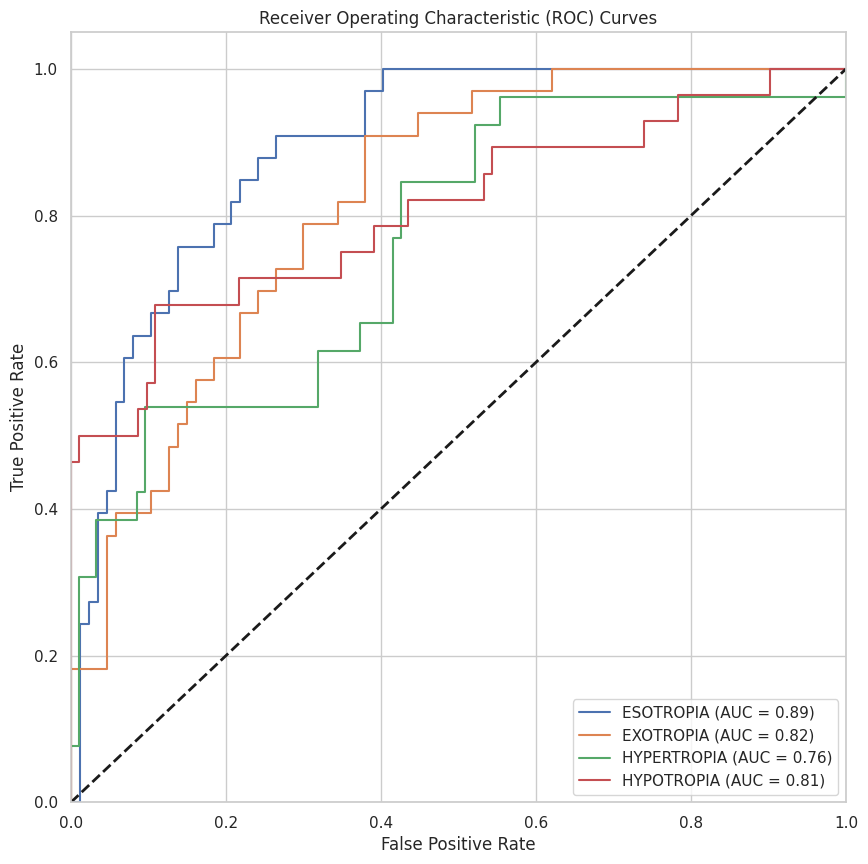

In [160]:
evaluator.plot_roc_curve()